In [27]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn import metrics
from kneed import KneeLocator

In [28]:

data_file = Path("..") / "data" / "data_processed" / "SUPERSTORE_DATASET_MODELAGEM.csv"
df = pd.read_csv(data_file, sep=",")

In [29]:
df_clustering = df[['SHIP_MODE', 'CUSTOMER_ID', 'SEGMENT', 'CATEGORY', 'REGION', 'NET_SALES', 'PROFIT','SUB_CATEGORY']]
df_clustering = df_clustering.reset_index(drop=True)

df_clustering = df_clustering.groupby('CUSTOMER_ID', as_index=False).agg({
    'SHIP_MODE': 'first',
    'SUB_CATEGORY': 'first',
    'CATEGORY': 'first',
    'REGION': 'first',
    'SEGMENT': 'first',
    'NET_SALES': 'sum',
    'PROFIT': 'sum'
})

X_scaled = df_clustering.drop(columns='CUSTOMER_ID')

In [30]:
df_clustering.head()

,CUSTOMER_ID,SHIP_MODE,SUB_CATEGORY,CATEGORY,REGION,SEGMENT,NET_SALES,PROFIT
0,AA-10315,STANDARD CLASS,APPLIANCES,OFFICE SUPPLIES,WEST,CONSUMER,10725.69280,-666.4136
1,AA-10375,STANDARD CLASS,BINDERS,OFFICE SUPPLIES,WEST,CONSUMER,2179.55640,206.9757
2,AA-10480,SAME DAY,FURNISHINGS,FURNITURE,EAST,CONSUMER,2148.77480,161.5842
3,AA-10645,STANDARD CLASS,CHAIRS,FURNITURE,EAST,CONSUMER,15335.94625,648.0864
4,AB-10015,STANDARD CLASS,STORAGE,OFFICE SUPPLIES,CENTRAL,CONSUMER,503.12800,65.1097


In [31]:
cols_one_hot = ['SHIP_MODE', 'SEGMENT', 'REGION', 'CATEGORY', 'SUB_CATEGORY']

for col in cols_one_hot:
    print(df_clustering[col].value_counts(), "\n")

SHIP_MODE
STANDARD CLASS    481
SECOND CLASS      157
FIRST CLASS       118
SAME DAY           37
Name: count, dtype: int64 

SEGMENT
CONSUMER       409
CORPORATE      236
HOME OFFICE    148
Name: count, dtype: int64 

REGION
WEST       252
EAST       204
CENTRAL    196
SOUTH      141
Name: count, dtype: int64 

CATEGORY
OFFICE SUPPLIES    493
FURNITURE          168
TECHNOLOGY         132
Name: count, dtype: int64 

SUB_CATEGORY
BINDERS        124
PAPER          100
ART             74
FURNISHINGS     71
STORAGE         66
PHONES          60
ACCESSORIES     57
CHAIRS          49
APPLIANCES      38
LABELS          31
TABLES          29
SUPPLIES        22
ENVELOPES       19
FASTENERS       19
BOOKCASES       19
MACHINES         8
COPIERS          7
Name: count, dtype: int64 



In [32]:
X_scaled = pd.get_dummies(
    X_scaled,
    columns=cols_one_hot)

In [33]:
cols_scaler = ['PROFIT', 'NET_SALES']

scaler = StandardScaler()
X_scaled[cols_scaler] = scaler.fit_transform(X_scaled[cols_scaler])

In [34]:
X_scaled.head()

,NET_SALES,PROFIT,SHIP_MODE_FIRST CLASS,SHIP_MODE_SAME DAY,SHIP_MODE_SECOND CLASS,SHIP_MODE_STANDARD CLASS,SEGMENT_CONSUMER,SEGMENT_CORPORATE,SEGMENT_HOME OFFICE,REGION_CENTRAL,REGION_EAST,REGION_SOUTH,REGION_WEST,CATEGORY_FURNITURE,CATEGORY_OFFICE SUPPLIES,CATEGORY_TECHNOLOGY,SUB_CATEGORY_ACCESSORIES,SUB_CATEGORY_APPLIANCES,SUB_CATEGORY_ART,SUB_CATEGORY_BINDERS,SUB_CATEGORY_BOOKCASES,SUB_CATEGORY_CHAIRS,SUB_CATEGORY_COPIERS,SUB_CATEGORY_ENVELOPES,SUB_CATEGORY_FASTENERS,SUB_CATEGORY_FURNISHINGS,SUB_CATEGORY_LABELS,SUB_CATEGORY_MACHINES,SUB_CATEGORY_PAPER,SUB_CATEGORY_PHONES,SUB_CATEGORY_STORAGE,SUB_CATEGORY_SUPPLIES,SUB_CATEGORY_TABLES
0,0.484276,-1.474409,False,False,False,True,True,False,False,False,False,False,True,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,-0.457770,0.010157,False,False,False,True,True,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
2,-0.461163,-0.066998,False,True,False,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
3,0.992467,0.759946,False,False,False,True,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
4,-0.642564,-0.230983,False,False,False,True,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False


In [35]:
# Range de clusters
k_range = range(2, 8)

results = {
    "k": [],
    "inertia": [],
    "silhouette": [],
    "calinski_harabasz": [],
    "davies_bouldin": [],
}

# Loop
for k in k_range:
    model = KMeans(n_clusters=k, 
        n_init=10,
        random_state=0,
        max_iter=200
    )
    labels = model.fit_predict(X_scaled)

    results["k"].append(k)
    results["inertia"].append(model.inertia_)
    results["silhouette"].append(
        metrics.silhouette_score(X_scaled, labels)
    )
    results["calinski_harabasz"].append(
        metrics.calinski_harabasz_score(X_scaled, labels)
    )
    results["davies_bouldin"].append(
        metrics.davies_bouldin_score(X_scaled, labels)
    )


df_metrics = pd.DataFrame(results).set_index("k")

knee = KneeLocator(
    x=df_metrics.index,
    y=df_metrics["inertia"],
    curve="convex",
    direction="decreasing"
)

k_optimal = knee.knee
if k_optimal is None:
    print("Elbow não encontrado")
    
k_sil = df_metrics["silhouette"].idxmax()
k_ch  = df_metrics["calinski_harabasz"].idxmax()
k_db  = df_metrics["davies_bouldin"].idxmin()

k_summary = pd.DataFrame({
    "method": ["silhouette", "calinski_harabasz", "davies_bouldin", "elbow"],
    "k": [k_sil, k_ch, k_db, k_optimal]
})

print("\nResumo dos melhores k:")
print(k_summary)


Resumo dos melhores k:
              method  k
0         silhouette  2
1  calinski_harabasz  2
2     davies_bouldin  3
3              elbow  4


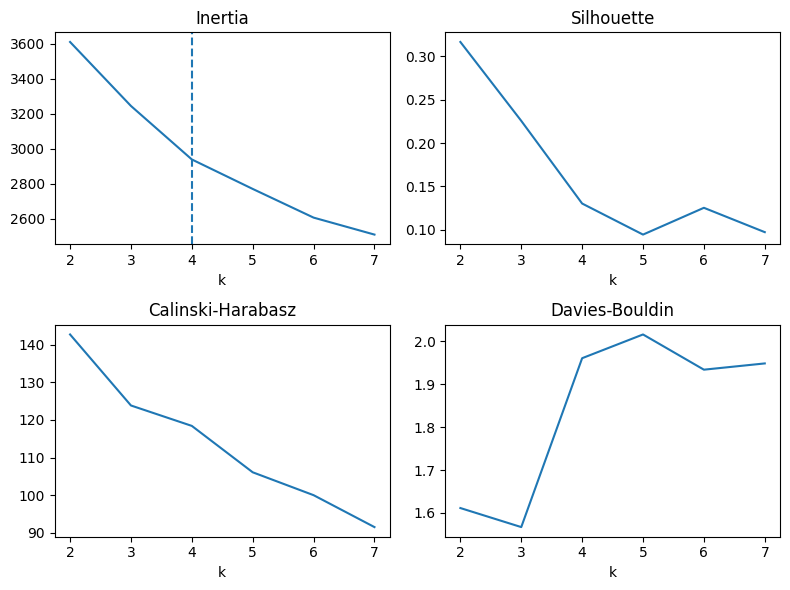

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

df_metrics["inertia"].plot(ax=axes[0, 0], title="Inertia")

if k_optimal is not None:
    axes[0, 0].axvline(k_optimal, linestyle="--")

df_metrics["silhouette"].plot(ax=axes[0, 1], title="Silhouette")
df_metrics["calinski_harabasz"].plot(ax=axes[1, 0], title="Calinski-Harabasz")
df_metrics["davies_bouldin"].plot(ax=axes[1, 1], title="Davies-Bouldin")

plt.tight_layout()
plt.show()

In [37]:
kmeans_publico = KMeans(n_clusters=3, 
        n_init=10,
        random_state=0
    )
kmeans_publico.fit(X_scaled)
labels = kmeans_publico.labels_

df_clustering['CLUSTER'] = labels


In [38]:
centroids = pd.DataFrame(
    kmeans_publico.cluster_centers_,
    columns=X_scaled.columns
)


centroids[cols_scaler] = scaler.inverse_transform(
    centroids[cols_scaler]
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

display(centroids.round(2))

,NET_SALES,PROFIT,SHIP_MODE_FIRST CLASS,SHIP_MODE_SAME DAY,SHIP_MODE_SECOND CLASS,SHIP_MODE_STANDARD CLASS,SEGMENT_CONSUMER,SEGMENT_CORPORATE,SEGMENT_HOME OFFICE,REGION_CENTRAL,REGION_EAST,REGION_SOUTH,REGION_WEST,CATEGORY_FURNITURE,CATEGORY_OFFICE SUPPLIES,CATEGORY_TECHNOLOGY,SUB_CATEGORY_ACCESSORIES,SUB_CATEGORY_APPLIANCES,SUB_CATEGORY_ART,SUB_CATEGORY_BINDERS,SUB_CATEGORY_BOOKCASES,SUB_CATEGORY_CHAIRS,SUB_CATEGORY_COPIERS,SUB_CATEGORY_ENVELOPES,SUB_CATEGORY_FASTENERS,SUB_CATEGORY_FURNISHINGS,SUB_CATEGORY_LABELS,SUB_CATEGORY_MACHINES,SUB_CATEGORY_PAPER,SUB_CATEGORY_PHONES,SUB_CATEGORY_STORAGE,SUB_CATEGORY_SUPPLIES,SUB_CATEGORY_TABLES
0,19255.45,791.14,0.22,0.02,0.23,0.53,0.44,0.36,0.20,0.23,0.30,0.15,0.32,0.24,0.57,0.19,0.08,0.01,0.07,0.11,0.03,0.08,0.02,0.01,0.01,0.08,0.02,0.01,0.20,0.08,0.12,0.02,0.05
1,3742.27,66.73,0.14,0.05,0.19,0.62,0.53,0.29,0.18,0.25,0.25,0.18,0.32,0.21,0.63,0.16,0.07,0.05,0.10,0.16,0.02,0.06,0.01,0.03,0.03,0.09,0.04,0.01,0.12,0.08,0.08,0.03,0.04
2,64247.97,4652.36,0.33,0.00,0.17,0.50,0.67,0.17,0.17,0.33,0.17,0.33,0.17,0.17,0.83,0.00,0.00,0.17,0.17,0.50,0.00,0.00,0.00,0.00,0.00,0.17,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [39]:
df_clustering['CLUSTER'].value_counts()

CLUSTER
1    678
0    109
2      6
Name: count, dtype: int64